In [1]:
# Download data from Zenodo (skip if already downloaded)
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'scripts'))
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'style'))
from download_data import download_all
from config import HIERARCHICAL_DIR

needed = ['sigma_posterior.h5', 'branching_fraction_posterior.h5']
if not all(os.path.exists(os.path.join(HIERARCHICAL_DIR, n)) for n in needed):
    download_all()
else:
    print(f'Data already present at {HIERARCHICAL_DIR}')

Data already present at /work/nihargupte/analysis/dingo/asimov/eccentricity/working/release/code/notebooks/../scripts/../../zenodo_data/hierarchical_inference


In [2]:
import json

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm

# Selection-corrected hierarchical run (Uniform-sigma): posterior samples of
# (population hyperparameters, sigma). sigma is in cm/s.
SIGMA_POSTERIOR = os.path.join(HIERARCHICAL_DIR, "sigma_posterior.h5")
post = pd.read_hdf(SIGMA_POSTERIOR, key="posterior")
sigma_cms = post["sigma"].to_numpy(float)
sigma_kms = sigma_cms / 1e5

with h5py.File(SIGMA_POSTERIOR) as f:
    run_config = json.loads(f.attrs["run_config"])
print(f"{len(sigma_cms)} posterior samples, {run_config['n_events']} events "
      f"(min max-SNR {run_config['min_max_snr']})")

# Prior: sigma ~ Uniform(0, 10^7.5) cm/s (the wide fiducial prior used by the
# unshipped inference pipeline; see run_config['run_config'] attrs above)
SIGMA_PRIOR_MIN_KMS = 0.0
SIGMA_PRIOR_MAX_KMS = 10 ** 7.5 / 1e5

6560 posterior samples, 56 events (min max-SNR 10.0)


In [3]:
from plot_style import initialize_latex, COLORS
initialize_latex()

In [4]:
# ============================================================
# GC / NSC observed 1D velocity dispersion catalogs (km/s)
# ============================================================
gc_sigma_1d_kms = np.array([
    12.2,  3.3,  8.8,  5.6,  6.1, 10.2,  6.5,  1.6,  7.1,  1.3,
    14.4,  1.8,  1.4,  4.5,  1.0,  3.1,  4.9,  2.5,  3.7,  4.8,
     5.9,  1.6, 17.6,  8.1,  9.3,  1.6,  5.3,  8.9,  3.1, 11.9,
     0.6,  3.9,  7.7,  6.5,  8.3,  0.8,  9.5,  4.6,  2.7,  2.2,
     9.2,  2.4,  4.3,  1.6,  9.2,  7.1,  4.5,  6.2,  4.5, 15.2,
    11.0,  8.9,  7.5,  5.7,  9.0,  8.0,  4.5,  7.8,  6.2,  4.4,
     3.0,  5.5,  3.9, 23.2,  7.8,  2.9, 18.2, 11.1,  5.2, 19.0,
    15.8, 18.8,  8.7,  3.4,  8.2,  2.8,  6.4,  5.9,  6.4,  8.7,
     8.5,  3.5,  3.3,  7.5,  4.2,  6.1, 12.6,  6.9,  8.4,  7.1,
     5.0, 16.2,  5.3,  3.2,  8.3,  7.2,  6.1,  0.8,  2.0,  4.8,
     1.4,  3.7,  3.3, 11.8,  4.7,  4.4, 12.9, 10.6,  5.5,  1.0,
     1.2,  1.4,
])

nsc_sigma_1d_kms = np.array([
     93.39,  23.99,  29.47,  30.88, 100.86,  67.15,  22.01,  10.43,
     82.51,  32.07,  41.97,  60.35,  79.84,  21.04,  25.49,  56.43,
     84.03, 238.72, 124.05,  50.19, 107.57,  30.83,  61.89,  46.21,
     72.63, 395.65, 186.72, 122.32,  61.95,  70.23,  35.37,  85.74,
     46.51, 101.82,  70.73,  90.77, 183.49,  28.98,  23.96,  27.47,
     89.98,  76.30,  52.59,  41.47,  87.39,  97.96,  41.09, 155.48,
     11.39,  23.61,  10.47,  99.99, 263.07,  90.98,  51.72,  32.17,
     20.99,  42.75,  67.15,  24.54,  66.11,  68.78,  74.14,  18.88,
     66.56,  13.23,  45.81,  61.78, 130.63,  24.66,  65.30,  33.76,
     28.30,  17.17,  63.38,  55.99, 234.18,  82.73,  38.90, 130.07,
     15.38,  20.32,  17.42,  84.08, 214.33, 111.53,  57.43,  15.56,
     34.77,  51.00, 122.30,   6.85,  33.94,  56.68,  28.17, 102.52,
     56.26,  30.72,  11.08,  33.89,  16.01,  36.58,  37.50,  34.38,
     24.13, 198.11,  61.89,  25.76,
])

# Log-normal fits (in log10 of cgs sigma, matching the paper convention)
gc_log10 = np.log10(gc_sigma_1d_kms * 1e5)
nsc_log10 = np.log10(nsc_sigma_1d_kms * 1e5)
gc_lognormal_params = {"mu": gc_log10.mean(), "std": gc_log10.std()}
nsc_lognormal_params = {"mu": nsc_log10.mean(), "std": nsc_log10.std()}
print(f"GC:  mu = {gc_lognormal_params['mu']:.4f}, std = {gc_lognormal_params['std']:.4f}")
print(f"NSC: mu = {nsc_lognormal_params['mu']:.4f}, std = {nsc_lognormal_params['std']:.4f}")

GC:  mu = 5.7094, std = 0.3306
NSC: mu = 6.7004, std = 0.3414


In [5]:
# --- branching-fraction posterior (B grid; beta = 1 - B is the NSC fraction) ---
BRANCHING = os.path.join(HIERARCHICAL_DIR, 'branching_fraction_posterior.h5')
with h5py.File(BRANCHING) as f:
    Bg = f['B_grid'][:]
    post_unif = f['posterior_uniform_prior'][:]
    post_beta = f['posterior_beta_prior'][:]
    prior_beta = f['prior_beta'][:]
    a_beta = float(f.attrs['beta_prior_alpha']); b_beta = float(f.attrs['beta_prior_beta'])
    n_obs = int(f.attrs['n_obs']); n_draw = int(f.attrs['n_draw'])
print(f'{n_obs} events, marginalized over {n_draw} GWTC-4 draws')
print(f'Beta prior: Beta(alpha={a_beta:.2f}, beta={b_beta:.2f}), mean B={a_beta/(a_beta+b_beta):.3f}')

# beta = 1 - B is the NSC fraction; flip the grid so the plots are in beta.
beta_grid = 1.0 - Bg

# Credible intervals are reported as highest-density intervals (HDIs), not
# equal-tailed (2-sided) intervals: the narrowest interval carrying the credible
# mass. For boundary-peaked posteriors (e.g. beta, which peaks at 0) the HDI is
# one-sided -- a bound sits at the grid/sample edge -- whereas an equal-tailed
# interval would spuriously push the lower bound off the boundary.
CRED = 0.90

def hdi_grid(grid, post, cred=CRED, n_scan=2000):
    """Median and `cred` HDI of a (possibly unnormalized) density on a grid."""
    order = np.argsort(grid); g = grid[order]; p = np.clip(post[order].astype(float), 0, None)
    cdf = np.concatenate([[0], np.cumsum(0.5 * (p[1:] + p[:-1]) * np.diff(g))]); cdf /= cdf[-1]
    quant = lambda u: np.interp(u, cdf, g)
    alphas = np.linspace(0.0, 1.0 - cred, n_scan)
    los, his = quant(alphas), quant(alphas + cred)
    j = int(np.argmin(his - los))
    return quant(0.5), los[j], his[j]

def hdi_samples(x, cred=CRED):
    """`cred` HDI from samples: the narrowest interval containing the mass."""
    xs = np.sort(np.asarray(x, float)); n = xs.size
    k = int(np.floor(cred * n))
    i = int(np.argmin(xs[k:] - xs[:n - k]))
    return xs[i], xs[i + k]

def summarize(grid, post, tag, cred=CRED):
    med, lo, hi = hdi_grid(grid, post, cred=cred)
    print(f'  {tag}: median={med:.3f}  {int(round(cred * 100))}% HDI [{lo:.3f}, {hi:.3f}]')
    return med, lo, hi

print('beta = NSC fraction (1 - B):')
beta_unif = summarize(beta_grid, post_unif, 'uniform prior ')
beta_betap = summarize(beta_grid, post_beta, 'rate-informed ')

# --- selection-corrected sigma posterior, expressed in log10 sigma [km/s] ---
log10_sigma_kms = np.log10(sigma_kms)
kde = gaussian_kde(log10_sigma_kms)
log10_sigma_fine = np.linspace(-1.0, 2.2, 2000)        # 0.1 ... ~158 km/s
sigma_fine_kms = 10 ** log10_sigma_fine
p_post_log10 = kde(log10_sigma_fine)                   # p(log10 sigma)
# Uniform-in-linear-sigma prior, expressed as a density in log10 sigma:
# p(log10 sigma) = ln(10) * sigma * p(sigma) = ln(10) * sigma / sigma_max.
prior_log10 = np.where(sigma_fine_kms <= SIGMA_PRIOR_MAX_KMS,
                       np.log(10) * sigma_fine_kms / SIGMA_PRIOR_MAX_KMS, 0.0)
# HDI on log10 sigma (the plotted coordinate); median is transform-invariant.
log10_sigma_median = float(np.median(log10_sigma_kms))
log10_sigma_lo, log10_sigma_hi = hdi_samples(log10_sigma_kms)

56 events, marginalized over 1439 GWTC-4 draws
Beta prior: Beta(alpha=23.27, beta=5.65), mean B=0.805
beta = NSC fraction (1 - B):
  uniform prior : median=0.159  90% HDI [0.000, 0.471]
  rate-informed : median=0.169  90% HDI [0.068, 0.280]


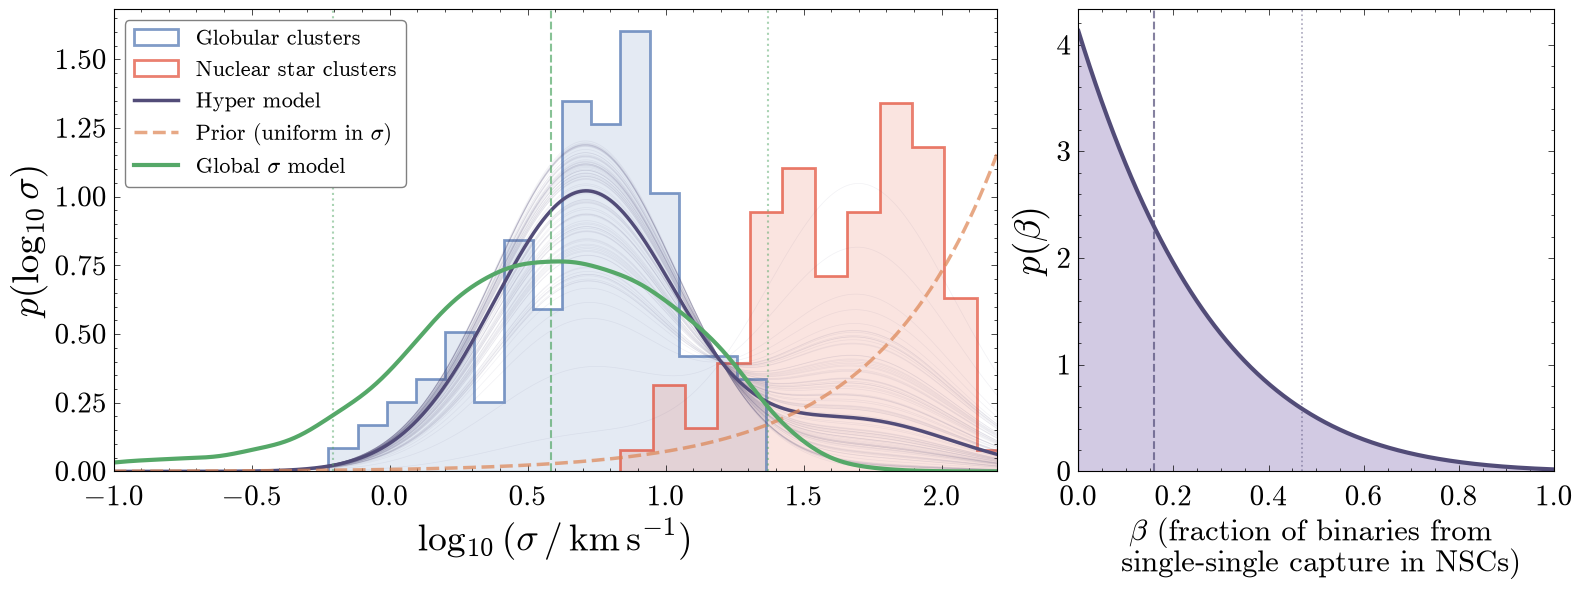

saved ../figures/ecc_sigma_combined_plot.pdf


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                               gridspec_kw={'width_ratios': [65, 35]})

# ---------------- LEFT: selection-corrected p(log10 sigma) ----------------
ax1.hist(np.log10(gc_sigma_1d_kms), bins=15, density=True, histtype='stepfilled',
         color=COLORS['blue'], alpha=0.15)
ax1.hist(np.log10(gc_sigma_1d_kms), bins=15, density=True, histtype='step',
         color=COLORS['blue'], lw=2, alpha=0.7, label='Globular clusters')
ax1.hist(np.log10(nsc_sigma_1d_kms), bins=15, density=True, histtype='stepfilled',
         color=COLORS['red'], alpha=0.15)
ax1.hist(np.log10(nsc_sigma_1d_kms), bins=15, density=True, histtype='step',
         color=COLORS['red'], lw=2, alpha=0.7, label='Nuclear star clusters')

# --- Hyper model: posterior-predictive sigma implied by the inferred NSC fraction beta ---
# Mixture model: p(log10 sigma | beta) = beta * NSC_fit + (1 - beta) * GC_fit.
# This is the same beta posterior shown in the right panel, so it shares its color.
# Show the median predictive curve plus 100 posterior draws as thin light lines.
gc_fit = norm.pdf(log10_sigma_fine, loc=gc_lognormal_params['mu'] - 5.0,
                  scale=gc_lognormal_params['std'])
nsc_fit = norm.pdf(log10_sigma_fine, loc=nsc_lognormal_params['mu'] - 5.0,
                   scale=nsc_lognormal_params['std'])
_order = np.argsort(beta_grid)
_bg, _pb = beta_grid[_order], post_unif[_order]
_cdf = np.concatenate([[0], np.cumsum(0.5 * (_pb[1:] + _pb[:-1]) * np.diff(_bg))])
_cdf /= _cdf[-1]
_rng = np.random.default_rng(0)
beta_draws = np.interp(_rng.random(4000), _cdf, _bg)
ppd_curves = (beta_draws[:, None] * nsc_fit[None, :]
              + (1.0 - beta_draws)[:, None] * gc_fit[None, :])
ppd_median = np.median(ppd_curves, axis=0)
for i in _rng.choice(ppd_curves.shape[0], size=100, replace=False):
    ax1.plot(log10_sigma_fine, ppd_curves[i], color=COLORS['dark purple'], lw=0.5, alpha=0.08)
ax1.plot(log10_sigma_fine, ppd_median, color=COLORS['dark purple'], lw=2.5,
         label=r'Hyper model')

ax1.plot(log10_sigma_fine, prior_log10, color=COLORS['orange'], ls='--', lw=2.5, alpha=0.7,
         label=r'Prior (uniform in $\sigma$)')
ax1.plot(log10_sigma_fine, p_post_log10, color=COLORS['green'], lw=3,
         label=r'Global $\sigma$ model')
# Vertical lines: median (dashed) and the 90% HDI bounds (dotted).
ax1.axvline(log10_sigma_median, color=COLORS['green'], ls='--', lw=1.5, alpha=0.7)
ax1.axvline(log10_sigma_lo, color=COLORS['green'], ls=':', lw=1.5, alpha=0.5)
ax1.axvline(log10_sigma_hi, color=COLORS['green'], ls=':', lw=1.5, alpha=0.5)
ax1.set_xlabel(r'$\log_{10}(\sigma\,/\,\mathrm{km\,s^{-1}})$', fontsize=27)
ax1.set_ylabel(r'$p(\log_{10}\sigma)$', fontsize=27)
ax1.set_xlim([-1.0, 2.2]); ax1.set_ylim(bottom=0)
ax1.tick_params(axis='both', labelsize=21)
ax1.tick_params(axis='x', pad=10)
ax1.legend(loc='upper left', fontsize=16, framealpha=1.0, edgecolor='grey', frameon=True)

# ---------------- RIGHT: GC/NSC branching fraction (beta = 1 - B) ----------------
# Two posteriors: the flat-prior result (uniform in B) and the rate-informed
# result that folds in the Beta(alpha, beta) prior on B from the GWTC-4 rate fit.
# Both densities are normalized to integrate to 1 over beta, so they overlay
# directly. Each posterior is shown with its prior (thin dashed) so the data's
# pull is visible. Vertical lines mark the median (dashed) and the 90% HDI
# bounds (dotted); the HDIs are one-sided where the posterior peaks at beta = 0.
# beta = 1 - B is a linear flip (unit Jacobian), so a prior density on B is the
# same density plotted against beta_grid = 1 - Bg.
ax2.fill_between(beta_grid, 0, post_unif, color=COLORS['purple'], alpha=0.30)
ax2.plot(beta_grid, post_unif, color=COLORS['dark purple'], lw=3,
         label=r'Uniform prior (posterior)')
ax2.axvline(beta_unif[0], color=COLORS['dark purple'], ls='--', lw=1.5, alpha=0.7)
for xq in (beta_unif[1], beta_unif[2]):
    ax2.axvline(xq, color=COLORS['dark purple'], ls=':', lw=1.2, alpha=0.5)

# Rate-informed posterior (Beta prior on B from the GWTC-4 rate fit).
# ax2.plot(beta_grid, post_beta, color=COLORS['maroon'], lw=3,
        #  label=r'Rate-informed prior (posterior)')
# ax2.axvline(beta_betap[0], color=COLORS['maroon'], ls='--', lw=1.5, alpha=0.7)
# for xq in (beta_betap[1], beta_betap[2]):
    # ax2.axvline(xq, color=COLORS['maroon'], ls=':', lw=1.2, alpha=0.5)
# Rate-informed (Beta) prior on B, expressed in beta = 1 - B.
# ax2.plot(beta_grid, prior_beta, color=COLORS['maroon'], ls='--', lw=1.8,
        #  alpha=0.6, label=r'Rate-informed prior')

ax2.set_xlabel(r'$\beta$ (fraction of binaries from ' + '\n' + ' single-single capture in NSCs)', fontsize=22)
ax2.set_ylabel(r'$p(\beta)$', fontsize=27)
ax2.set_xlim([0, 1]); ax2.set_ylim(bottom=0)
ax2.tick_params(axis='both', labelsize=21)
ax2.tick_params(axis='x', pad=10)

plt.tight_layout()
plt.savefig('../figures/ecc_sigma_combined_plot.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('saved ../figures/ecc_sigma_combined_plot.pdf')

In [7]:
# ============================================================
# Summary statistics (paper numbers)
# ============================================================
levels = [5, 16, 50, 84, 95]
pct = np.percentile(sigma_kms, levels)
# 90% HDI matching the figure: the plotted HDI is on log10 sigma, so convert
# those same bounds back to km/s (HDIs are not transform-invariant).
sigma_hdi_lo_kms, sigma_hdi_hi_kms = 10 ** log10_sigma_lo, 10 ** log10_sigma_hi
print("=" * 70)
print("Selection-corrected velocity dispersion posterior (1D sigma):")
print("=" * 70)
for lvl, val in zip(levels, pct):
    print(f"  {lvl:>2d}%: {val:8.1f} km/s")
print(f"\n  Median:                        {pct[2]:.1f} km/s")
print(f"  90% HDI:                       [{sigma_hdi_lo_kms:.1f}, {sigma_hdi_hi_kms:.1f}] km/s")
print(f"  1-sided 95% upper bound: sigma < {pct[4]:.1f} km/s")
print("=" * 70)

print()
print("GC branching fraction B (= R_GC / (R_GC + R_NSC)):")
summarize(Bg, post_unif, 'B, uniform prior ')
summarize(Bg, post_beta, 'B, rate-informed ')
print()
print("NSC fraction beta = 1 - B:")
print(f"  uniform prior : {beta_unif[0]:.2f}  90% HDI [{beta_unif[1]:.2f}, {beta_unif[2]:.2f}]")
print(f"  rate-informed : {beta_betap[0]:.2f}  90% HDI [{beta_betap[1]:.2f}, {beta_betap[2]:.2f}]")
print("=" * 70)

Selection-corrected velocity dispersion posterior (1D sigma):
   5%:      0.5 km/s
  16%:      1.2 km/s
  50%:      3.9 km/s
  84%:     11.6 km/s
  95%:     19.7 km/s

  Median:                        3.9 km/s
  90% HDI:                       [0.6, 23.6] km/s
  1-sided 95% upper bound: sigma < 19.7 km/s

GC branching fraction B (= R_GC / (R_GC + R_NSC)):
  B, uniform prior : median=0.841  90% HDI [0.529, 1.000]
  B, rate-informed : median=0.831  90% HDI [0.720, 0.932]

NSC fraction beta = 1 - B:
  uniform prior : 0.16  90% HDI [0.00, 0.47]
  rate-informed : 0.17  90% HDI [0.07, 0.28]
